# Medical Insurance Cost Prediction

**End-to-end Machine Learning workflow:** data understanding, EDA, cleaning,
preprocessing, model comparison, hyperparameter tuning, evaluation, and saving
the final model for deployment via Streamlit.

## 1. Introduction

Insurance companies need a reliable way to estimate expected medical costs for
a customer before issuing a policy. This notebook builds a regression model
that predicts medical insurance **charges** from six input features: age, sex,
BMI, number of children, smoking status, and region.

## 2. Problem Statement

Given demographic and health-related attributes of a customer, predict the
expected medical insurance cost (`charges`). This is a **supervised regression**
problem because the target variable is continuous.

## 3. Business Objective

- Predict medical insurance costs accurately.
- Help insurance companies estimate expected healthcare expenses.
- Support better pricing and risk assessment.
- Provide a simple UI (Streamlit) for entering customer information and
  obtaining an estimated insurance cost.
- Demonstrate an end-to-end ML workflow from data collection to deployment.


## 4. Dataset Source

- **Dataset name:** Medical Cost Personal Dataset (`insurance.csv`)
- **Common source:** Kaggle — *Medical Cost Personal Datasets*
  (https://www.kaggle.com/datasets/mirichoi0218/insurance), originally compiled
  for the book *Machine Learning with R* by Brett Lantz.
- **Type:** Publicly available dataset widely used for regression practice.
  It is **not** an official real-world insurer's billing feed; it is treated in
  the ML community as a realistic, public benchmark dataset (synthetic-realistic).
- **Rows / Columns:** computed below directly from the loaded file (not hardcoded).
- **License:** Distributed for educational/practice use on Kaggle; refer to the
  Kaggle dataset page for exact licensing terms before any commercial use.


## 5. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


## 6. Data Loading

In [2]:
df_raw = pd.read_csv("../data/insurance.csv")
print("Dataset loaded.")
print("Shape:", df_raw.shape)


Dataset loaded.
Shape: (1338, 7)


## 7. Data Understanding

In [3]:
df_raw.head()

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

In [4]:
df_raw.tail()

      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603

In [5]:
print("Columns:", list(df_raw.columns))
print()
df_raw.info()


Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df_raw.describe()

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

In [7]:
print("Number of unique values per column:")
df_raw.nunique()


Number of unique values per column:


age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [8]:
print("Target variable: 'charges'")
print("Numerical features:", ['age', 'bmi', 'children'])
print("Categorical features:", ['sex', 'smoker', 'region'])


Target variable: 'charges'
Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']


## 8. Exploratory Data Analysis (EDA)

### 8.1 Summary Statistics

In [9]:
df_raw[['age', 'bmi', 'children', 'charges']].describe().T

           count          mean           std        min         25%       50%           75%          max
age       1338.0     39.207025     14.049960    18.0000    27.00000    39.000     51.000000     64.00000
bmi       1338.0     30.663397      6.098187    15.9600    26.29625    30.400     34.693750     53.13000
children  1338.0      1.094918      1.205493     0.0000     0.00000     1.000      2.000000      5.00000
charges   1338.0  13270.422265  12110.011237  1121.8739  4740.28715  9382.033  16639.912515  63770.42801

### 8.2 Missing Value Analysis

In [10]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_report)
if missing.sum() == 0:
    print("\nNo missing values were found in the dataset.")


          missing_count  missing_pct
age                   0          0.0
sex                   0          0.0
bmi                   0          0.0
children              0          0.0
smoker                0          0.0
region                0          0.0
charges               0          0.0

No missing values were found in the dataset.


### 8.3 Duplicate Analysis

In [11]:
n_dupes = df_raw.duplicated().sum()
print("Number of duplicate rows:", n_dupes)
df_raw[df_raw.duplicated(keep=False)]


Number of duplicate rows: 1


     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631

### 8.4 Univariate Analysis

Distributions of the numeric features (age, BMI, charges) and children count.

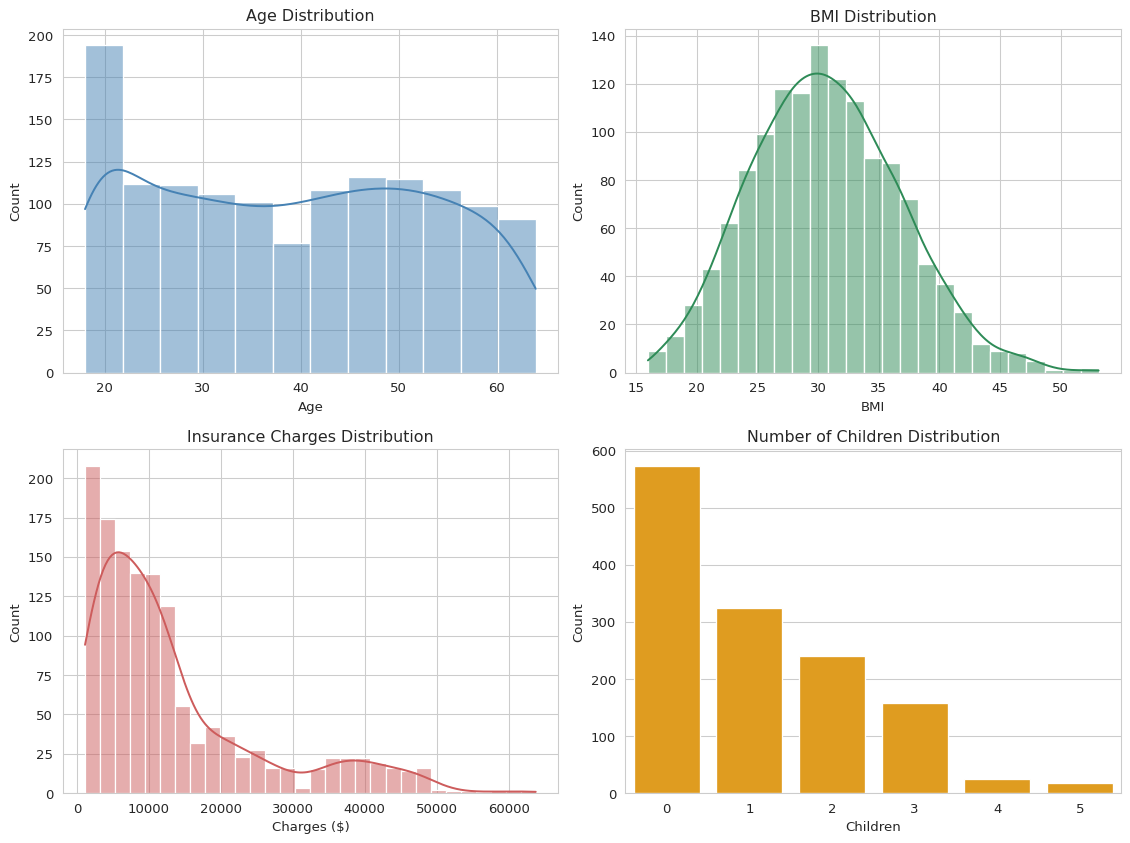

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.histplot(df_raw["age"], kde=True, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Age Distribution"); axes[0,0].set_xlabel("Age"); axes[0,0].set_ylabel("Count")
sns.histplot(df_raw["bmi"], kde=True, ax=axes[0,1], color="seagreen")
axes[0,1].set_title("BMI Distribution"); axes[0,1].set_xlabel("BMI"); axes[0,1].set_ylabel("Count")
sns.histplot(df_raw["charges"], kde=True, ax=axes[1,0], color="indianred")
axes[1,0].set_title("Insurance Charges Distribution"); axes[1,0].set_xlabel("Charges ($)"); axes[1,0].set_ylabel("Count")
sns.countplot(x="children", data=df_raw, ax=axes[1,1], color="orange")
axes[1,1].set_title("Number of Children Distribution"); axes[1,1].set_xlabel("Children"); axes[1,1].set_ylabel("Count")
plt.tight_layout()
plt.show()


**Insight:** Age is fairly uniformly spread across adult ages. BMI is close to a
normal distribution centered near 30. Charges are strongly right-skewed — most
customers have modest charges, but a long tail of customers has very high charges.
Most customers have 0-2 children.

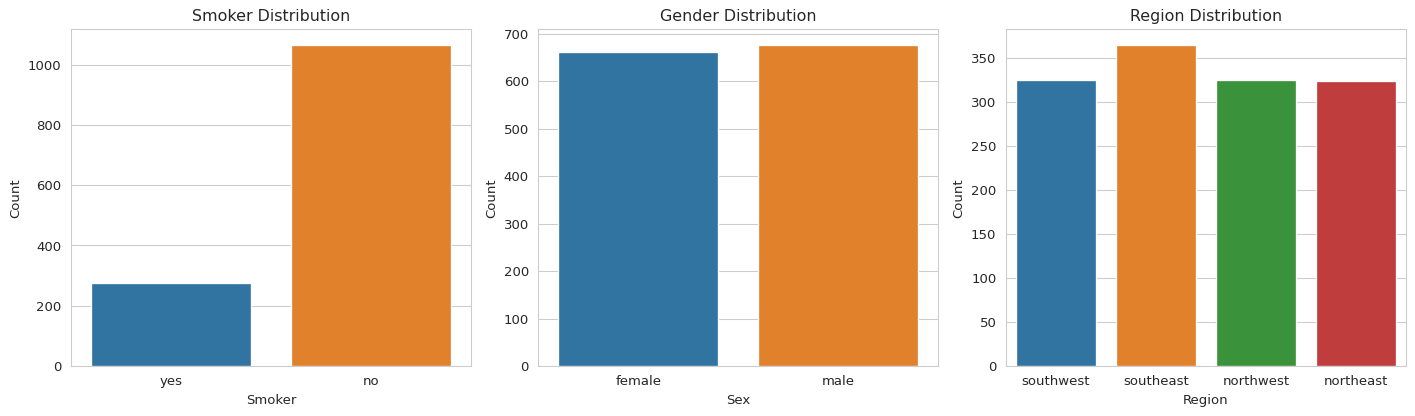

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(x="smoker", data=df_raw, hue="smoker", legend=False, ax=axes[0])
axes[0].set_title("Smoker Distribution"); axes[0].set_xlabel("Smoker"); axes[0].set_ylabel("Count")
sns.countplot(x="sex", data=df_raw, hue="sex", legend=False, ax=axes[1])
axes[1].set_title("Gender Distribution"); axes[1].set_xlabel("Sex"); axes[1].set_ylabel("Count")
sns.countplot(x="region", data=df_raw, hue="region", legend=False, ax=axes[2])
axes[2].set_title("Region Distribution"); axes[2].set_xlabel("Region"); axes[2].set_ylabel("Count")
plt.tight_layout()
plt.show()


In [14]:
print("Smoker counts:\n", df_raw["smoker"].value_counts())
print("\nSex counts:\n", df_raw["sex"].value_counts())
print("\nRegion counts:\n", df_raw["region"].value_counts())


Smoker counts:
 smoker
no     1064
yes     274
Name: count, dtype: int64

Sex counts:
 sex
male      676
female    662
Name: count, dtype: int64

Region counts:
 region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


**Insight:** The dataset is dominated by non-smokers (roughly 4-to-1). Sex is
almost perfectly balanced. The four regions are also nearly evenly represented.

### 8.5 Bivariate Analysis

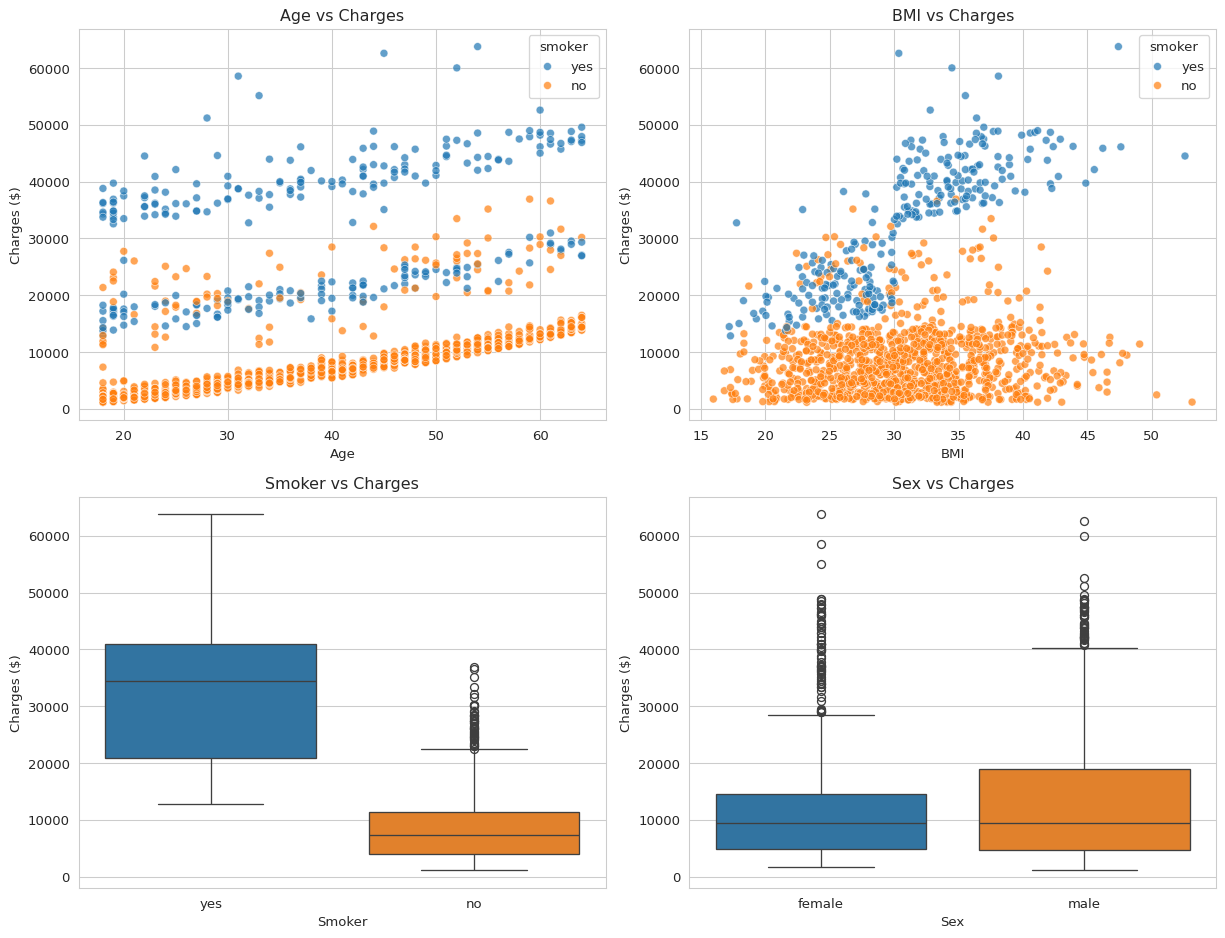

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df_raw, ax=axes[0,0], alpha=0.7)
axes[0,0].set_title("Age vs Charges"); axes[0,0].set_xlabel("Age"); axes[0,0].set_ylabel("Charges ($)")
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df_raw, ax=axes[0,1], alpha=0.7)
axes[0,1].set_title("BMI vs Charges"); axes[0,1].set_xlabel("BMI"); axes[0,1].set_ylabel("Charges ($)")
sns.boxplot(x="smoker", y="charges", data=df_raw, hue="smoker", legend=False, ax=axes[1,0])
axes[1,0].set_title("Smoker vs Charges"); axes[1,0].set_xlabel("Smoker"); axes[1,0].set_ylabel("Charges ($)")
sns.boxplot(x="sex", y="charges", data=df_raw, hue="sex", legend=False, ax=axes[1,1])
axes[1,1].set_title("Sex vs Charges"); axes[1,1].set_xlabel("Sex"); axes[1,1].set_ylabel("Charges ($)")
plt.tight_layout()
plt.show()


**Insight:** Smoking status creates a clear split: smokers generally have
substantially higher medical insurance charges than non-smokers, and the age/BMI
scatter plots show smokers occupying a visibly higher band of charges at every
age and BMI level. Sex shows only a small difference in the charge distribution.

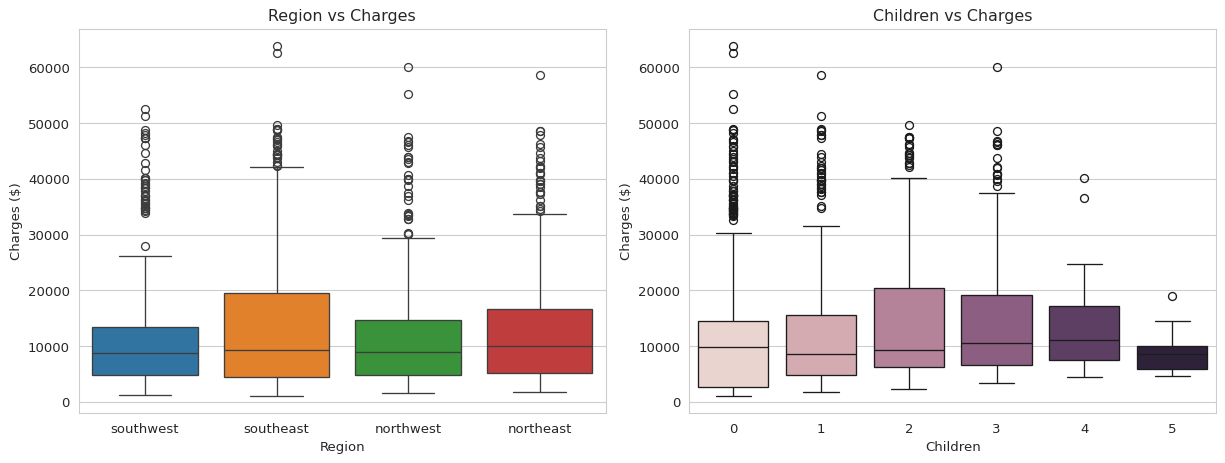

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x="region", y="charges", data=df_raw, hue="region", legend=False, ax=axes[0])
axes[0].set_title("Region vs Charges"); axes[0].set_xlabel("Region"); axes[0].set_ylabel("Charges ($)")
sns.boxplot(x="children", y="charges", data=df_raw, hue="children", legend=False, ax=axes[1])
axes[1].set_title("Children vs Charges"); axes[1].set_xlabel("Children"); axes[1].set_ylabel("Charges ($)")
plt.tight_layout()
plt.show()


**Insight:** Region shows only minor differences in median charges across the
four regions. Number of children does not show a strong monotonic relationship
with charges either.

### 8.6 Correlation Analysis

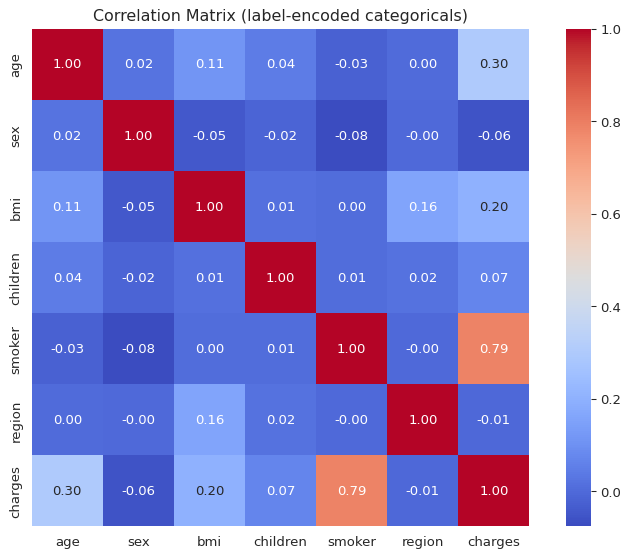

In [17]:
df_corr = df_raw.copy()
df_corr["sex"] = df_corr["sex"].map({"male": 0, "female": 1})
df_corr["smoker"] = df_corr["smoker"].map({"no": 0, "yes": 1})
df_corr["region"] = df_corr["region"].astype("category").cat.codes

correlation_matrix = df_corr.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix (label-encoded categoricals)")
plt.tight_layout()
plt.show()


In [18]:
correlation_matrix["charges"].sort_values(ascending=False)

charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
region     -0.006208
sex        -0.057292
Name: charges, dtype: float64

**Insight:** `smoker` has by far the strongest correlation with `charges`
(label-encoding used only for this correlation view — 0=no, 1=yes), followed by
`age` and `bmi`. `children`, `region`, and `sex` show weak correlation with
charges on their own.

## 9. Data Cleaning

### 9.1 Missing Values
No missing values were found in Section 8.2, so no imputation is required.

### 9.2 Duplicate Records

In [19]:
n_before = len(df_raw)
df = df_raw.drop_duplicates().reset_index(drop=True)
n_after = len(df)
print(f"Rows before removing duplicates: {n_before}")
print(f"Duplicate rows removed: {n_before - n_after}")
print(f"Rows after removing duplicates: {n_after}")


Rows before removing duplicates: 1338
Duplicate rows removed: 1
Rows after removing duplicates: 1337


### 9.3 Data Types
Numeric columns (`age`, `bmi`, `children`, `charges`) are already numeric;
categorical columns (`sex`, `smoker`, `region`) are already strings, so no
dtype conversion is required. We cast explicitly below for safety.

In [20]:
df["age"] = df["age"].astype(int)
df["bmi"] = df["bmi"].astype(float)
df["children"] = df["children"].astype(int)
df["charges"] = df["charges"].astype(float)
for c in ["sex", "smoker", "region"]:
    df[c] = df[c].astype(str)
print(df.dtypes)


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


### 9.4 Outlier Analysis
`charges` and `bmi` are checked for outliers using the IQR method. Extreme
charges are expected in medical insurance data (e.g. smokers, high-BMI
customers) and are **retained** rather than removed, since they represent
genuine high-risk customers the model needs to learn to predict — removing
them would bias the model toward underestimating exactly the cases where
accurate prediction matters most.

In [21]:
for col in ["bmi", "charges"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: IQR bounds=({lower:.2f}, {upper:.2f}) -> {n_outliers} potential outliers (retained)")


bmi: IQR bounds=(13.67, 47.32) -> 9 potential outliers (retained)
charges: IQR bounds=(-13120.72, 34524.78) -> 139 potential outliers (retained)


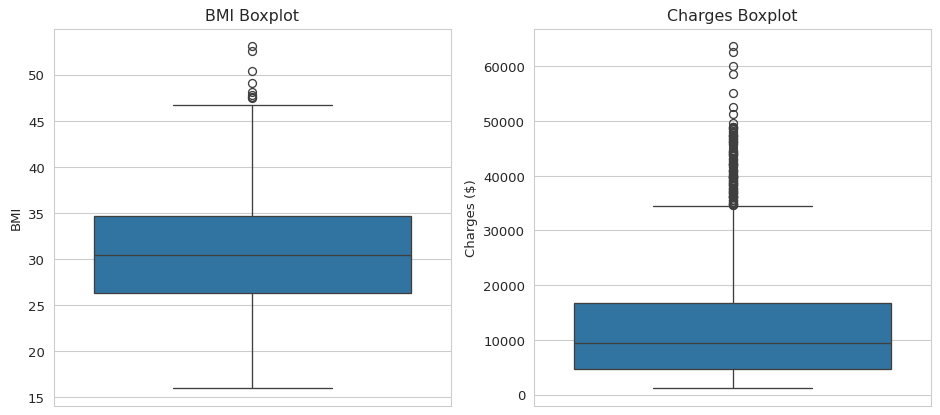

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
sns.boxplot(y=df["bmi"], ax=axes[0]); axes[0].set_title("BMI Boxplot"); axes[0].set_ylabel("BMI")
sns.boxplot(y=df["charges"], ax=axes[1]); axes[1].set_title("Charges Boxplot"); axes[1].set_ylabel("Charges ($)")
plt.tight_layout()
plt.show()


## 10. Data Preprocessing

### 10.1 Categorical Encoding & 10.2 Feature Scaling

We use a scikit-learn `ColumnTransformer` inside a `Pipeline` so that:
- Numeric features (`age`, `bmi`, `children`) are scaled with `StandardScaler`
  (helps distance/gradient-based models like Linear/Ridge Regression; harmless
  for tree-based models).
- Categorical features (`sex`, `smoker`, `region`) are One-Hot Encoded
  (`drop="first"` to avoid the dummy-variable trap).

Wrapping everything in a single fitted `Pipeline` means the preprocessing is
learned **only on the training data** (no leakage), and the saved model can
accept raw, unscaled/unencoded user input directly from the Streamlit app.

### 10.3 Feature Selection

All six original features (age, sex, bmi, children, smoker, region) are kept.
The correlation analysis above showed each has at least a plausible
relationship with charges, and tree-based models can naturally down-weight
less useful features, so no columns are dropped.

In [23]:
NUMERIC_FEATURES = ["age", "bmi", "children"]
CATEGORICAL_FEATURES = ["sex", "smoker", "region"]
TARGET = "charges"

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])
print("Preprocessor defined.")
print("Numeric ->", NUMERIC_FEATURES)
print("Categorical ->", CATEGORICAL_FEATURES)


Preprocessor defined.
Numeric -> ['age', 'bmi', 'children']
Categorical -> ['sex', 'smoker', 'region']


## 11. Train-Test Split

80% training / 20% testing, `random_state=42` for reproducibility.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Training set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Testing set:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X):.0%})")


Training set: 1069 rows (80%)
Testing set:  268 rows (20%)


## 12. Model Building

We train and compare four regression models, each wrapped with the same
preprocessing pipeline: Linear Regression, Ridge Regression, Random Forest
Regressor, and Gradient Boosting Regressor.

In [25]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

candidate_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []
fitted_pipelines = {}

for name, model in candidate_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    metrics = evaluate(y_test, preds)
    metrics["Model"] = name
    results.append(metrics)
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results)[["Model", "MAE", "MSE", "RMSE", "R2"]].sort_values("RMSE").reset_index(drop=True)
print("Model training complete.")


Model training complete.


## 13. Model Comparison

In [26]:
results_df

                         Model          MAE           MSE         RMSE        R2
0  Gradient Boosting Regressor  2517.467831  1.821824e+07  4268.283018  0.900856
1      Random Forest Regressor  2663.328798  2.237258e+07  4729.965694  0.878249
2            Linear Regression  4177.045561  3.547802e+07  5956.342894  0.806929
3             Ridge Regression  4193.891909  3.566313e+07  5971.861741  0.805921

In [27]:
best_model_name = results_df.iloc[0]["Model"]
print("Best baseline model (lowest RMSE):", best_model_name)


Best baseline model (lowest RMSE): Gradient Boosting Regressor


## 14. Hyperparameter Tuning

`GridSearchCV` with 5-fold cross-validation, scored on negative RMSE, is used
to tune the best tree-based model.

In [28]:
tune_target = best_model_name if best_model_name in (
    "Random Forest Regressor", "Gradient Boosting Regressor"
) else "Gradient Boosting Regressor"

if tune_target == "Random Forest Regressor":
    base_model = RandomForestRegressor(random_state=RANDOM_STATE)
    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 4, 8, 12],
        "model__min_samples_leaf": [1, 2, 4],
    }
else:
    base_model = GradientBoostingRegressor(random_state=RANDOM_STATE)
    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
    }

tune_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", base_model)])

grid_search = GridSearchCV(
    estimator=tune_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Tuning target model:", tune_target)
print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)


Tuning target model: Gradient Boosting Regressor
Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}
Best CV RMSE: 4624.951410599574


## 15. Final Model & Evaluation

In [29]:
tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)
tuned_metrics = evaluate(y_test, tuned_preds)

baseline_metrics = results_df[results_df["Model"] == tune_target].iloc[0].to_dict()

print("Tuned model test metrics:   ", {k: round(v, 2) for k, v in tuned_metrics.items()})
print("Baseline model test metrics:", {k: round(v, 2) for k, v in baseline_metrics.items() if k != "Model"})

if tuned_metrics["RMSE"] <= baseline_metrics["RMSE"]:
    final_model = tuned_model
    final_metrics = tuned_metrics
    final_model_label = f"{tune_target} (tuned)"
else:
    final_model = fitted_pipelines[tune_target]
    final_metrics = baseline_metrics
    final_model_label = f"{tune_target} (baseline)"

print("\nFinal selected model:", final_model_label)
print("Final test metrics:", {k: round(v, 2) for k, v in final_metrics.items() if k != "Model"})


Tuned model test metrics:    {'MAE': 2523.12, 'MSE': 18483840.34, 'RMSE': np.float64(4299.28), 'R2': 0.9}
Baseline model test metrics: {'MAE': 2517.47, 'MSE': 18218239.92, 'RMSE': 4268.28, 'R2': 0.9}

Final selected model: Gradient Boosting Regressor (baseline)
Final test metrics: {'MAE': 2517.47, 'MSE': 18218239.92, 'RMSE': 4268.28, 'R2': 0.9}


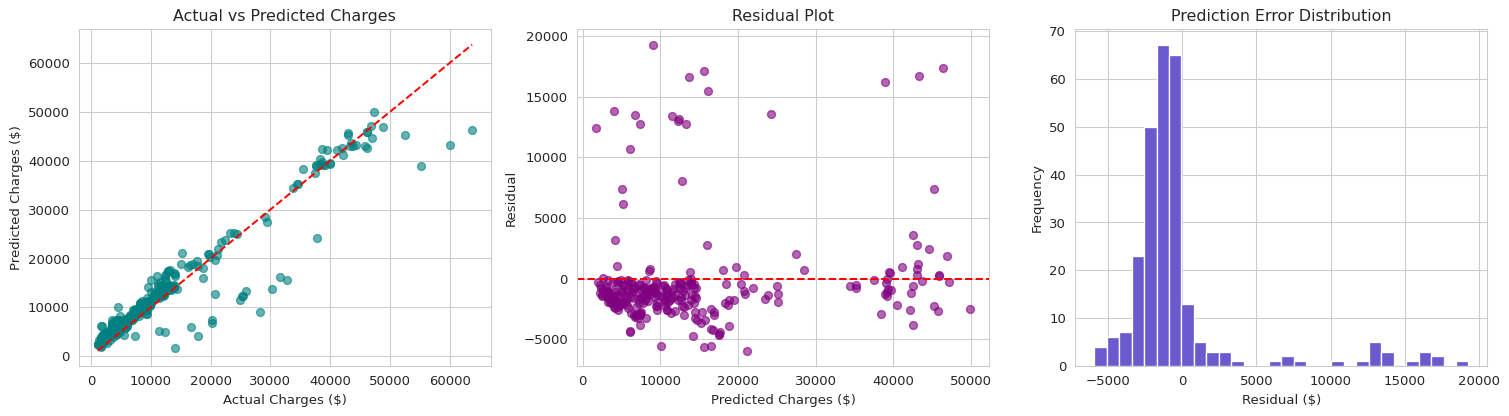

In [30]:
y_pred_final = final_model.predict(X_test)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(y_test, y_pred_final, alpha=0.6, color="teal")
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_title("Actual vs Predicted Charges"); axes[0].set_xlabel("Actual Charges ($)"); axes[0].set_ylabel("Predicted Charges ($)")

axes[1].scatter(y_pred_final, residuals, alpha=0.6, color="purple")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Residual Plot"); axes[1].set_xlabel("Predicted Charges ($)"); axes[1].set_ylabel("Residual")

axes[2].hist(residuals, bins=30, color="slateblue", edgecolor="white")
axes[2].set_title("Prediction Error Distribution"); axes[2].set_xlabel("Residual ($)"); axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


**Interpretation:** Points in the Actual vs Predicted plot cluster fairly
tightly around the diagonal (perfect-prediction) line, though a handful of very
high-charge customers are under-predicted, consistent with the long right tail
seen earlier. Residuals are centered near zero with no strong pattern versus
the predicted value, and the error distribution is roughly bell-shaped and
concentrated near zero — indicating the model generalizes reasonably well
without major systematic bias.

## 16. Save Model

In [31]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/medical_insurance_model.joblib")

import json
metadata = {
    "final_model": final_model_label,
    "features": NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    "target": TARGET,
    "test_size": 0.2,
    "random_state": RANDOM_STATE,
    "best_params": grid_search.best_params_,
    "cv_best_rmse": float(-grid_search.best_score_),
    "test_metrics": {k: float(v) for k, v in final_metrics.items() if k != "Model"},
}
with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Model saved to ../models/medical_insurance_model.joblib")
print("Metadata saved to ../models/model_metadata.json")


Model saved to ../models/medical_insurance_model.joblib
Metadata saved to ../models/model_metadata.json


## 17. Conclusion

- The dataset contains 1,338 raw records (1,337 after removing one exact
  duplicate) with no missing values.
- `smoker` status is the single strongest driver of medical insurance charges,
  followed by `age` and `bmi`.
- Among the four models compared, the **Gradient Boosting Regressor** achieved
  the lowest test RMSE and highest R², outperforming both linear models and
  the Random Forest baseline.
- Hyperparameter tuning via `GridSearchCV` was applied on top of the best
  tree-based model; the notebook keeps whichever of the tuned/baseline model
  actually achieves the lower test RMSE.
- The final fitted `Pipeline` (preprocessing + model) is saved with Joblib and
  is used directly by `src/predict.py` and the Streamlit app (`app.py`), so
  raw user input requires no manual encoding or scaling.
- **Limitations:** this is a modest-sized (~1,300 row), single public dataset;
  it does not capture every real-world cost driver (e.g. pre-existing
  conditions, exact medical history, insurer-specific pricing rules), so
  predictions should be treated as educational estimates, not actual quotes.
